# Load Data

We need to access the data via Django's settings. The next cell initializes SQLAlchemy's engine to connect to the Digital Twin's database.

In [1]:
import os

from sqlalchemy import create_engine
from django.conf import settings

os.environ["DJANGO_SETTINGS_MODULE"] = "twin4dem.settings"
db = settings.DATABASES["default"]
engine = create_engine(
    f"postgresql://{db['USER']}:{db['PASSWORD']}@{db['HOST']}:{db['PORT']}/{db['NAME']}"
)

The next thing to do is load the data we want to use in a Pandas DataFrame.

In [2]:
import pandas as pd

df = pd.read_sql("SELECT * FROM simulation_log_entries", engine)
display(df)

,simulation_id,step_no,submodel_type,agent_id,label,is_powerful,weights,vote_value
0,23,4,executive,141,admin-simulation-000023-cabinet-pm,True,"0.3402760105045699,0.31556189011521035,0.22262...",1.0
1,23,4,executive,142,admin-simulation-000023-cabinet-01,False,"0.31053356398058524,0.07771586627314596,0.1260...",1.0
2,23,4,executive,143,admin-simulation-000023-cabinet-02,False,"0.20751190813910467,0.11461240592848004,0.5277...",1.0
3,23,4,executive,144,admin-simulation-000023-cabinet-03,False,"0.1288335280716243,0.043321355504964236,0.2144...",1.0
4,23,4,executive,145,admin-simulation-000023-cabinet-04,False,"0.0030568369755090974,0.018389232235324793,0.2...",1.0
...,...,...,...,...,...,...,...,...
3621,23,122,legislative,464,admin-simulation-000023-parliament-B-member-004,False,"0.15178317293800309,0.3862818819798075,0.00231...",0.0
3622,23,122,legislative,465,admin-simulation-000023-parliament-B-member-005,False,"0.003186713215840707,0.5068812723287331,0.3954...",0.0
3623,23,122,legislative,466,admin-simulation-000023-parliament-B-member-006,False,"0.1947643074974551,0.09266255506566042,0.02324...",1.0
3624,23,122,legislative,467,admin-simulation-000023-parliament-B-member-007,False,"0.07961695001872529,0.13185518220396514,0.3940...",0.0


That seems to have worked spectacularly. Let's extract helper functions that allow us to create dataframes easily.

In [3]:
def new_connection():
    os.environ["DJANGO_SETTINGS_MODULE"] = "twin4dem.settings"
    db = settings.DATABASES["default"]
    return create_engine(
        f"postgresql://{db['USER']}:{db['PASSWORD']}@{db['HOST']}:{db['PORT']}/{db['NAME']}"
    )


def sql_to_df(sql_query, params=None):
    """Execute raw SQL and return a DataFrame."""
    connection = new_connection()
    return pd.read_sql(sql_query, connection, params=params)


df = sql_to_df("SELECT * FROM simulation_log_entries")
display(df)

,simulation_id,step_no,submodel_type,agent_id,label,is_powerful,weights,vote_value
0,23,4,executive,141,admin-simulation-000023-cabinet-pm,True,"0.3402760105045699,0.31556189011521035,0.22262...",1.0
1,23,4,executive,142,admin-simulation-000023-cabinet-01,False,"0.31053356398058524,0.07771586627314596,0.1260...",1.0
2,23,4,executive,143,admin-simulation-000023-cabinet-02,False,"0.20751190813910467,0.11461240592848004,0.5277...",1.0
3,23,4,executive,144,admin-simulation-000023-cabinet-03,False,"0.1288335280716243,0.043321355504964236,0.2144...",1.0
4,23,4,executive,145,admin-simulation-000023-cabinet-04,False,"0.0030568369755090974,0.018389232235324793,0.2...",1.0
...,...,...,...,...,...,...,...,...
3621,23,122,legislative,464,admin-simulation-000023-parliament-B-member-004,False,"0.15178317293800309,0.3862818819798075,0.00231...",0.0
3622,23,122,legislative,465,admin-simulation-000023-parliament-B-member-005,False,"0.003186713215840707,0.5068812723287331,0.3954...",0.0
3623,23,122,legislative,466,admin-simulation-000023-parliament-B-member-006,False,"0.1947643074974551,0.09266255506566042,0.02324...",1.0
3624,23,122,legislative,467,admin-simulation-000023-parliament-B-member-007,False,"0.07961695001872529,0.13185518220396514,0.3940...",0.0


Right. Seems we have enough to go on for now. Let's do a couple of basic stats.

In [4]:
query = """
SELECT
    simulation_id,
    step_no,
    submodel_type,
    COUNT(*) FILTER (WHERE NULLIF(vote_value, 'null'::jsonb)::int = 1) AS votes_for,
    COUNT(*) FILTER (WHERE NULLIF(vote_value, 'null'::jsonb)::int = 0) AS votes_against,
    COUNT(*) FILTER (WHERE vote_value IS NULL OR vote_value = 'null') AS abstentions,
    COUNT(*) AS total_votes
FROM simulation_log_entries
WHERE simulation_id=%s
GROUP BY simulation_id, step_no, submodel_type
ORDER BY simulation_id, step_no, submodel_type
"""
votes_over_time_df = sql_to_df(query, params=(23,))
display(votes_over_time_df)

,simulation_id,step_no,submodel_type,votes_for,votes_against,abstentions,total_votes
0,23,4,executive,7,0,0,7
1,23,4,legislative,5,29,0,34
2,23,5,executive,7,0,0,7
3,23,5,legislative,6,28,0,34
4,23,6,executive,7,0,0,7
...,...,...,...,...,...,...,...
233,23,120,judiciary,0,5,0,5
234,23,121,executive,7,0,0,7
235,23,121,legislative,5,29,0,34
236,23,122,executive,7,0,0,7


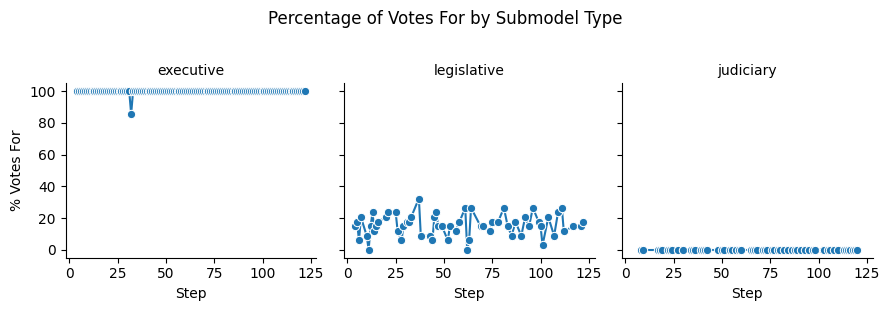

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


votes_over_time_df["pct_for"] = (
    votes_over_time_df["votes_for"] / votes_over_time_df["total_votes"] * 100
)

g = sns.FacetGrid(votes_over_time_df, col="submodel_type", col_wrap=3, height=3)
g.map_dataframe(sns.lineplot, x="step_no", y="pct_for", marker="o")
g.set_axis_labels("Step", "% Votes For")
g.set_titles("{col_name}")
g.fig.suptitle("Percentage of Votes For by Submodel Type", y=1.02)
plt.tight_layout()
plt.show()